In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
CV_FOLDS = 5

In [2]:
Xc, yc = make_classification(
    n_samples=400, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.1, flip_y=0.05,
    random_state=RANDOM_STATE,
)


Classification:
  Single Stump | CV accuracy: 0.8625 +/- 0.0426
  AdaBoost     | CV accuracy: 0.8400 +/- 0.0289


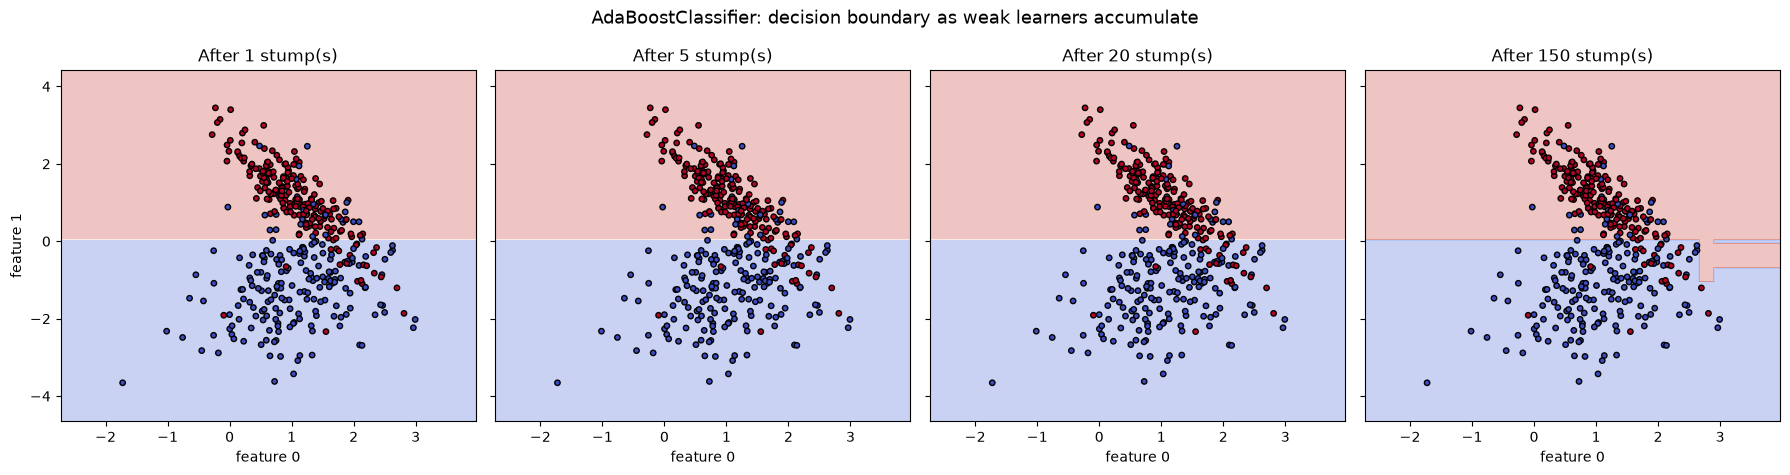

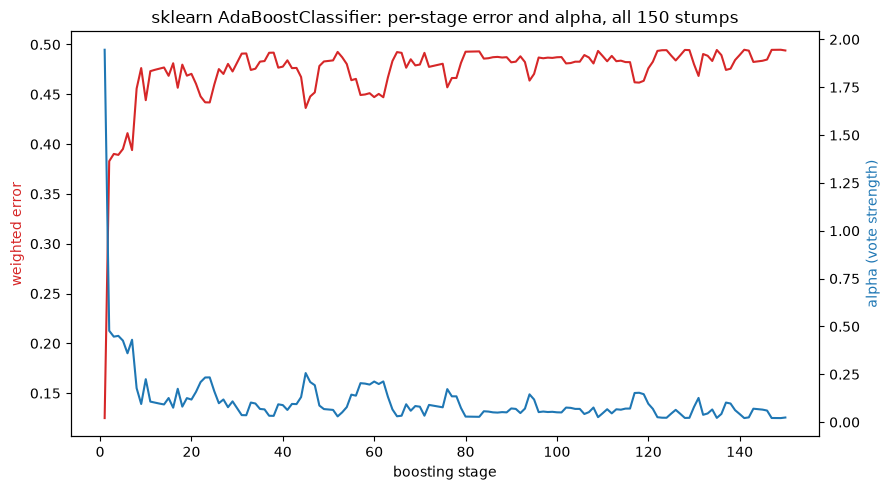

In [3]:
single_stump_c = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
ada_c = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=150, learning_rate=1.0, random_state=RANDOM_STATE,
)

print("\nClassification:")
for name, model in [("Single Stump", single_stump_c), ("AdaBoost", ada_c)]:
    scores = cross_val_score(model, Xc, yc, cv=CV_FOLDS, scoring="accuracy")
    print(f"  {name:12s} | CV accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

ada_c.fit(Xc, yc)


def make_checkpoints(n_stages, desired=(1, 5, 20, 150)):
    """AdaBoost can stop early (e.g. a stump reaches >=0.5 weighted error, or
    a perfect fit is found), so the requested checkpoints get clipped to
    however many stages were actually built, deduplicated, and sorted."""
    return sorted(set(min(c, n_stages) for c in desired))


# decision boundary sharpening as more weak learners are added
h = 0.03
x_min, x_max = Xc[:, 0].min() - 1, Xc[:, 0].max() + 1
y_min, y_max = Xc[:, 1].min() - 1, Xc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

staged_preds = list(ada_c.staged_predict(grid))
stage_checkpoints = make_checkpoints(len(staged_preds))

fig, axes = plt.subplots(1, len(stage_checkpoints), figsize=(4.5 * len(stage_checkpoints), 4.8), sharey=True)
if len(stage_checkpoints) == 1:
    axes = [axes]
for ax, n_est in zip(axes, stage_checkpoints):
    Z = staged_preds[n_est - 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap=plt.cm.coolwarm, edgecolor="k", s=15)
    ax.set_title(f"After {n_est} stump(s)")
    ax.set_xlabel("feature 0")
axes[0].set_ylabel("feature 1")
fig.suptitle("AdaBoostClassifier: decision boundary as weak learners accumulate", fontsize=13)
plt.tight_layout()
plt.show()

# error / alpha across ALL 150 stages (sklearn tracks these natively)
fig, ax1 = plt.subplots(figsize=(9, 5))
stages = np.arange(1, len(ada_c.estimator_errors_) + 1)
ax1.plot(stages, ada_c.estimator_errors_, color="tab:red", label="weighted error")
ax1.set_xlabel("boosting stage")
ax1.set_ylabel("weighted error", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(stages, ada_c.estimator_weights_, color="tab:blue", label="alpha (vote strength)")
ax2.set_ylabel("alpha (vote strength)", color="tab:blue")
ax1.set_title("sklearn AdaBoostClassifier: per-stage error and alpha, all 150 stumps")
fig.tight_layout()
plt.show()

In [5]:
Xr, yr = make_regression(
    n_samples=300, n_features=1, noise=15, random_state=RANDOM_STATE
)
yr = yr + 0.002 * (Xr[:, 0] ** 3)

  Single Stump | CV r2: 0.4719 +/- 0.0717
  AdaBoost     | CV r2: 0.7144 +/- 0.0317
  (AdaBoostRegressor actually built 10 stage(s) before stopping)


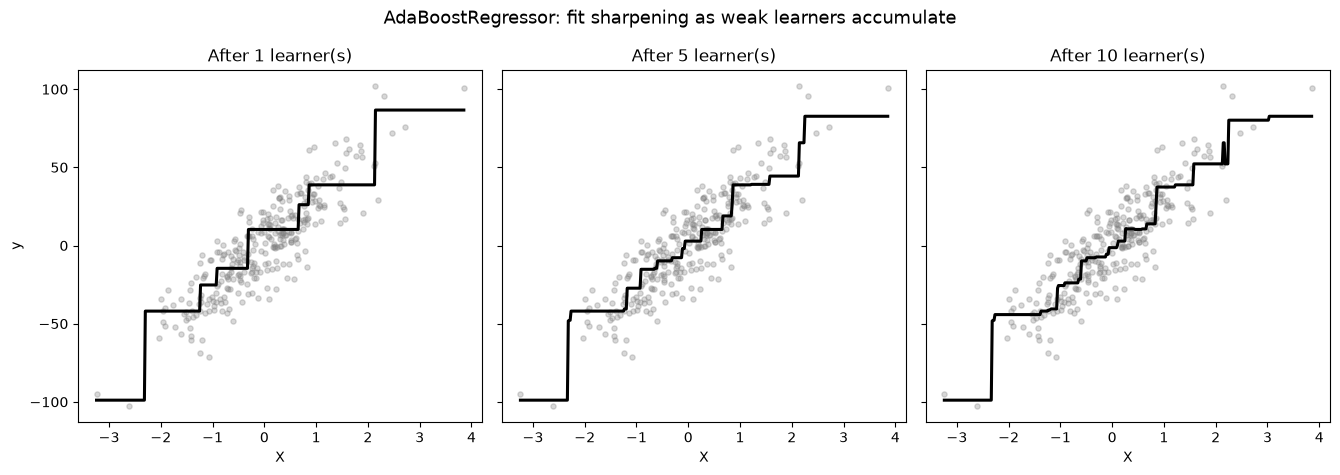

In [6]:
single_stump_r = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)
ada_r = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    n_estimators=150, learning_rate=1.0, random_state=RANDOM_STATE,
)

for name, model in [("Single Stump", single_stump_r), ("AdaBoost", ada_r)]:
    scores = cross_val_score(model, Xr, yr, cv=CV_FOLDS, scoring="r2")
    print(f"  {name:12s} | CV r2: {scores.mean():.4f} +/- {scores.std():.4f}")

ada_r.fit(Xr, yr)
x_line = np.linspace(Xr[:, 0].min(), Xr[:, 0].max(), 400).reshape(-1, 1)
staged_lines = list(ada_r.staged_predict(x_line))
reg_stage_checkpoints = make_checkpoints(len(staged_lines))
print(f"  (AdaBoostRegressor actually built {len(staged_lines)} stage(s) before stopping)")

fig, axes = plt.subplots(1, len(reg_stage_checkpoints), figsize=(4.5 * len(reg_stage_checkpoints), 4.8), sharey=True)
if len(reg_stage_checkpoints) == 1:
    axes = [axes]
for ax, n_est in zip(axes, reg_stage_checkpoints):
    ax.scatter(Xr, yr, color="gray", alpha=0.3, s=14)
    ax.plot(x_line, staged_lines[n_est - 1], color="black", linewidth=2.2)
    ax.set_title(f"After {n_est} learner(s)")
    ax.set_xlabel("X")
axes[0].set_ylabel("y")
fig.suptitle("AdaBoostRegressor: fit sharpening as weak learners accumulate", fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
param_dist_clf = {
    "n_estimators": [50, 100, 150, 250, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0, 1.5],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
        DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    ],
}

search_clf = RandomizedSearchCV(
    AdaBoostClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist_clf,
    n_iter=25, cv=CV_FOLDS, scoring="accuracy",
    random_state=RANDOM_STATE, n_jobs=-1,
)
search_clf.fit(Xc, yc)

print("\nClassifier:")
print(f"  Default (depth-1 stump, 150 est) CV accuracy: "
      f"{cross_val_score(ada_c, Xc, yc, cv=CV_FOLDS, scoring='accuracy').mean():.4f}")
print(f"  Best CV accuracy                            : {search_clf.best_score_:.4f}")
print(f"  Best params                                 : {search_clf.best_params_}")

param_dist_reg = {
    "n_estimators": [50, 100, 150, 250, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0, 1.5],
    "loss": ["linear", "square", "exponential"],
    "estimator": [
        DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE),
        DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE),
        DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    ],
}

search_reg = RandomizedSearchCV(
    AdaBoostRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist_reg,
    n_iter=25, cv=CV_FOLDS, scoring="r2",
    random_state=RANDOM_STATE, n_jobs=-1,
)
search_reg.fit(Xr, yr)

print("\nRegressor:")
print(f"  Default (depth-3 stump, 150 est) CV r2 : "
      f"{cross_val_score(ada_r, Xr, yr, cv=CV_FOLDS, scoring='r2').mean():.4f}")
print(f"  Best CV r2                             : {search_reg.best_score_:.4f}")
print(f"  Best params                            : {search_reg.best_params_}")



Classifier:
  Default (depth-1 stump, 150 est) CV accuracy: 0.8400
  Best CV accuracy                            : 0.8675
  Best params                                 : {'n_estimators': 50, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=42)}

Regressor:
  Default (depth-3 stump, 150 est) CV r2 : 0.7144
  Best CV r2                             : 0.7377
  Best params                            : {'n_estimators': 250, 'loss': 'linear', 'learning_rate': 0.01, 'estimator': DecisionTreeRegressor(max_depth=3, random_state=42)}
